In [89]:
from pathlib import Path
import math

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [90]:
SITES_COORDS = {
    "toulouse": (43.6047, 1.4442),
    "mauguio": (43.6167, 3.9667),
    "clermont-ferrand": (45.7772, 3.0870),
    "zurich": (47.3769, 8.5417),
}


def calculate_solar_zenith(date_value, site_name):
    """Calcule l'angle zenithal solaire depuis l'heure locale de prise de vue."""
    if pd.isna(date_value):
        return np.nan

    site_key = "zurich" if str(site_name).lower().startswith("zurich/") else str(site_name).lower()
    if site_key not in SITES_COORDS:
        return np.nan

    date_value = pd.Timestamp(date_value)
    latitude, longitude = SITES_COORDS[site_key]
    day_of_year = date_value.day_of_year
    declination = math.radians(
        23.45 * math.sin(math.radians(360.0 / 365.0 * (284 + day_of_year)))
    )
    b_angle = math.radians(360.0 / 365.0 * (day_of_year - 81))
    equation_of_time = (
        9.87 * math.sin(2 * b_angle)
        - 7.53 * math.cos(b_angle)
        - 1.5 * math.sin(b_angle)
    )

    # UTC+2 pendant l'heure d'ete, UTC+1 sinon.
    utc_offset = 2 if 4 <= date_value.month <= 9 else 1
    standard_meridian = 15 * utc_offset
    time_correction = 4 * (longitude - standard_meridian) + equation_of_time
    local_solar_time = (
        date_value.hour
        + date_value.minute / 60
        + date_value.second / 3600
        + time_correction / 60
    )
    hour_angle = math.radians(15 * (local_solar_time - 12))
    latitude = math.radians(latitude)
    cosine = (
        math.sin(latitude) * math.sin(declination)
        + math.cos(latitude) * math.cos(declination) * math.cos(hour_angle)
    )
    return math.degrees(math.acos(max(-1.0, min(1.0, cosine))))


In [91]:
# Le notebook doit etre lance depuis la racine du projet ou son sous-dossier notebooks.
root_candidates = (Path.cwd(), Path.cwd().parent)
CSV_PATH = next(
    (root / "csv" / "SPAD_indices_merged.csv" for root in root_candidates
     if (root / "csv" / "SPAD_indices_merged.csv").is_file()),
    None,
)
if CSV_PATH is None:
    raise FileNotFoundError("csv/SPAD_indices_merged.csv est introuvable")

df = pd.read_csv(CSV_PATH)

# Le nouveau CSV ne contient plus de colonne 'class'. Tous les sites disponibles
# sont selectionnes automatiquement, y compris toutes les dates de Zurich.
ALL_SITES = sorted(df["Site"].dropna().unique())
SELECTED_SITES = ALL_SITES
df = df[df["Site"].isin(SELECTED_SITES)].copy()

REQUIRED_COLUMNS = [
    "spad_mean", "DateTime",
    "Mean_R", "Mean_G", "Mean_B", "Mean_NIR",
    "Mean_rb_index", "Mean_br_bnir_index", "Mean_ci_green",
    "Mean_nir_b_gb_index", "Mean_nir_gb_ratio_index",
]
missing_columns = [column for column in REQUIRED_COLUMNS if column not in df.columns]
if missing_columns:
    raise ValueError(f"Colonnes absentes du nouveau CSV : {missing_columns}")

for column in REQUIRED_COLUMNS:
    if column != "DateTime":
        df[column] = pd.to_numeric(df[column], errors="coerce")
df = df.dropna(subset=REQUIRED_COLUMNS).copy()

sites = df["Site"].copy()
print(f"CSV : {CSV_PATH}")
print(f"Donnees retenues ({df['Site'].nunique()} sites) : {df.shape}")
print(df["Site"].value_counts())


CSV : d:\zakaria\csv\SPAD_indices_merged.csv
Donnees retenues (8 sites) : (510, 58)
Site
mauguio              104
toulouse              99
clermont-ferrand      70
zurich/2026-04-21     52
zurich/2026-05-05     52
zurich/2026-03-23     51
zurich/2026-06-01     46
zurich/2026-04-07     36
Name: count, dtype: int64


In [92]:
# Filtre optionnel : adapter cette liste pour travailler sur un sous-ensemble.
# SELECTED_SITES = ["toulouse", "mauguio", "clermont-ferrand"]
# df = df[df["Site"].isin(SELECTED_SITES)].copy()

sites = df["Site"].copy()
print(f"Donnees retenues ({df['Site'].nunique()} sites) : {df.shape}")
print(df["Site"].value_counts())


Donnees retenues (8 sites) : (510, 58)
Site
mauguio              104
toulouse              99
clermont-ferrand      70
zurich/2026-04-21     52
zurich/2026-05-05     52
zurich/2026-03-23     51
zurich/2026-06-01     46
zurich/2026-04-07     36
Name: count, dtype: int64


In [93]:
df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")
df = df.dropna(subset=["DateTime"]).copy()
df["solar_zenith"] = df.apply(
    lambda row: calculate_solar_zenith(row["DateTime"], row["Site"]), axis=1
)
df["solar_elevation"] = 90.0 - df["solar_zenith"]


In [94]:
# Les indices ont deja ete calcules pixel par pixel sous le masque combine
# par processing/spad_indices_pipeline.py. On utilise directement leurs stats.
INDEX_MEAN_COLUMNS = [
    "Mean_rb_index",
    "Mean_br_bnir_index",
    "Mean_ci_green",
    "Mean_nir_b_gb_index",
    "Mean_nir_gb_ratio_index",
]
df[INDEX_MEAN_COLUMNS].describe()


,Mean_rb_index,Mean_br_bnir_index,Mean_ci_green,Mean_nir_b_gb_index,Mean_nir_gb_ratio_index
count,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.140896,-0.033716,9.406637,20.979775,22.750003
std,0.050910,0.015026,2.624793,4.473708,4.777377
min,-0.080927,-0.077014,4.712920,12.536550,13.765942
25%,0.118269,-0.044110,7.738386,17.877046,19.479017
50%,0.149257,-0.033432,8.867357,20.599609,22.231690
75%,0.170415,-0.023408,10.649353,23.081845,24.855818
max,0.278419,0.014030,17.994740,39.391145,42.821447


In [95]:
df.columns

Index(['Site', 'Plot', 'spad_mean', 'Variete', 'Image', 'Date', 'DateTime',
       'ISOSpeedRatings_rgb', 'ExposureTime_rgb', 'ISOSpeedRatings_nir',
       'ExposureTime_nir', 'Feuille_1', 'Feuille_2', 'Feuille_3', 'Nb_pixels',
       'Mean_rb_index', 'Median_rb_index', 'Mode_rb_index',
       'Mean_br_bnir_index', 'Median_br_bnir_index', 'Mode_br_bnir_index',
       'Mean_ci_green', 'Median_ci_green', 'Mode_ci_green',
       'Mean_nir_b_gb_index', 'Median_nir_b_gb_index', 'Mode_nir_b_gb_index',
       'Mean_nir_gb_ratio_index', 'Median_nir_gb_ratio_index',
       'Mode_nir_gb_ratio_index', 'Mean_R', 'Median_R', 'Mode_R', 'Mean_G',
       'Median_G', 'Mode_G', 'Mean_B', 'Median_B', 'Mode_B', 'Mean_NIR',
       'Median_NIR', 'Mode_NIR', 'intensite_mire_R', 'intensite_mire_G',
       'intensite_mire_B', 'intensite_mire_NIR', 'DN_gris_R', 'DN_gris_G',
       'DN_gris_B', 'DN_gris_NIR', 'intensite_mire_noir_R',
       'intensite_mire_noir_NIR', 'intensite_mire_blanc_R',
       'intensite_m

In [96]:
# Les intensites de mire sont deja integrees dans SPAD_indices_merged.csv.
MIRE_COLUMNS = [
    "intensite_mire_R", "intensite_mire_G",
    "intensite_mire_B", "intensite_mire_NIR",
    "DN_gris_R", "DN_gris_G", "DN_gris_B", "DN_gris_NIR",
    "rgb_TI", "rgb_gain", "nir_TI", "nir_gain",
]
missing_mire_columns = [column for column in MIRE_COLUMNS if column not in df.columns]
if missing_mire_columns:
    raise ValueError(f"Colonnes de mire absentes : {missing_mire_columns}")

print("Colonnes de mire chargees depuis le CSV final.")
df[["Image", "intensite_mire_R", "intensite_mire_NIR", "DN_gris_R", "DN_gris_NIR"]].head()


Colonnes de mire chargees depuis le CSV final.


,Image,intensite_mire_R,intensite_mire_NIR,DN_gris_R,DN_gris_NIR
0,PlotP0126A2B02_Tricam1Camera1_1.png,8545.398605,3925.879623,157.524169,14.368719
1,PlotP0126A2B03_Tricam1Camera1_1.png,7647.427419,3712.507995,134.868500,13.587779
2,PlotP0126A2B04_Tricam1Camera1_1.png,8007.989061,3708.845361,128.766062,14.019435
3,PlotP0126A2B05_Tricam1Camera1_1.png,7748.809500,3528.362638,154.279572,18.160835
4,PlotP0126A2B06_Tricam1Camera1_1.png,7724.511732,3530.964168,152.254761,16.624485


In [97]:
TARGET = "spad_mean"

# Deux indices utilises dans la version precedente, maintenant lus directement
# depuis le nouveau CSV, sans recalcul dans le notebook.
feature_cols = [
    "Mean_rb_index",
    "Mean_br_bnir_index",
]

model_data = df.dropna(subset=[TARGET, *feature_cols]).copy()
X = model_data[feature_cols]
y = model_data[TARGET]
model_sites = model_data["Site"]
print(f"{len(feature_cols)} features utilisees sur {len(model_data)} observations :")
X.head()


2 features utilisees sur 510 observations :


,Mean_rb_index,Mean_br_bnir_index
0,0.101128,-0.024783
1,0.111785,-0.033627
2,0.121439,-0.030347
3,0.104600,-0.032314
4,0.058222,-0.019939


## Recherche exhaustive de la meilleure combinaison de features

In [98]:
# from itertools import combinations

# Toutes les features candidates du nouveau pipeline.
# ALL_CANDIDATE_FEATURES = [
#     "Mean_rb_index",
#     "Mean_br_bnir_index",
#     "Mean_ci_green",
#     "Mean_nir_b_gb_index",
#     "Mean_nir_gb_ratio_index",
#     "Mean_R", "Mean_G", "Mean_B", "Mean_NIR",
#     "solar_zenith",
#     "intensite_mire_R", "intensite_mire_G",
#     "intensite_mire_B", "intensite_mire_NIR",
# ]

# Le code de recherche exhaustive peut etre reactive ici si necessaire.


In [99]:
# # --- Classement par R² LOSO (le plus exigeant : robustesse au changement de site) ---
# results_by_loso = results_df.sort_values("R2_LOSO", ascending=False).reset_index(drop=True)
# print("=== TOP 15 — triées par R² LOSO (validation par site) ===")
# print(results_by_loso.head(15).to_string(index=False))

# # --- Classement par R² KFold aléatoire k=3 ---
# results_by_kfold = results_df.sort_values("R2_KFold3", ascending=False).reset_index(drop=True)
# print("\n=== TOP 15 — triées par R² KFold(k=3) aléatoire ===")
# print(results_by_kfold.head(15).to_string(index=False))

# best_loso = results_by_loso.iloc[0]
# best_kfold = results_by_kfold.iloc[0]

# print("\n=== Meilleure combinaison (LOSO) ===")
# print(f"  Features : {best_loso['features']}")
# print(f"  R² LOSO   : {best_loso['R2_LOSO']:.4f}  |  RMSE LOSO   : {best_loso['RMSE_LOSO']:.3f}")
# print(f"  R² KFold3 : {best_loso['R2_KFold3']:.4f}  |  RMSE KFold3 : {best_loso['RMSE_KFold3']:.3f}")

# print("\n=== Meilleure combinaison (KFold k=3) ===")
# print(f"  Features : {best_kfold['features']}")
# print(f"  R² KFold3 : {best_kfold['R2_KFold3']:.4f}  |  RMSE KFold3 : {best_kfold['RMSE_KFold3']:.3f}")
# print(f"  R² LOSO   : {best_kfold['R2_LOSO']:.4f}  |  RMSE LOSO   : {best_kfold['RMSE_LOSO']:.3f}")

# # Sauvegarde de tous les résultats pour inspection ultérieure
# results_df.to_csv("feature_combinations_results.csv", index=False)
# print("\nRésultats complets sauvegardés dans feature_combinations_results.csv")


In [100]:
X_train, X_test, y_train, y_test, site_train, site_test = train_test_split(
    X, y, model_sites, test_size=0.2, random_state=RANDOM_STATE, stratify=model_sites
)

# La régression linéaire est sensible à l'échelle des features -> standardisation
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [101]:
final_model = LinearRegression()
final_model.fit(X_train_s, y_train)
y_pred_test = final_model.predict(X_test_s)

r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("RÉSULTATS SUR LE TEST SET :")
print(f"  • R²   : {r2_test:.4f}")
print(f"  • MAE  : {mae_test:.3f} unités SPAD")
print(f"  • RMSE : {rmse_test:.3f} unités SPAD")

RÉSULTATS SUR LE TEST SET :
  • R²   : 0.5882
  • MAE  : 2.113 unités SPAD
  • RMSE : 2.634 unités SPAD


=== Métriques par site (Test Set) ===
             Site  N_test     R2  RMSE   MAE
 clermont-ferrand      14  0.095 3.260 2.673
          mauguio      21 -0.129 3.047 2.340
         toulouse      20  0.613 2.819 2.271
zurich/2026-03-23      10 -0.747 1.539 1.284
zurich/2026-04-07       7  0.458 1.604 1.422
zurich/2026-04-21      11  0.599 2.100 1.746
zurich/2026-05-05      10  0.149 1.826 1.577
zurich/2026-06-01       9 -2.306 3.005 2.868


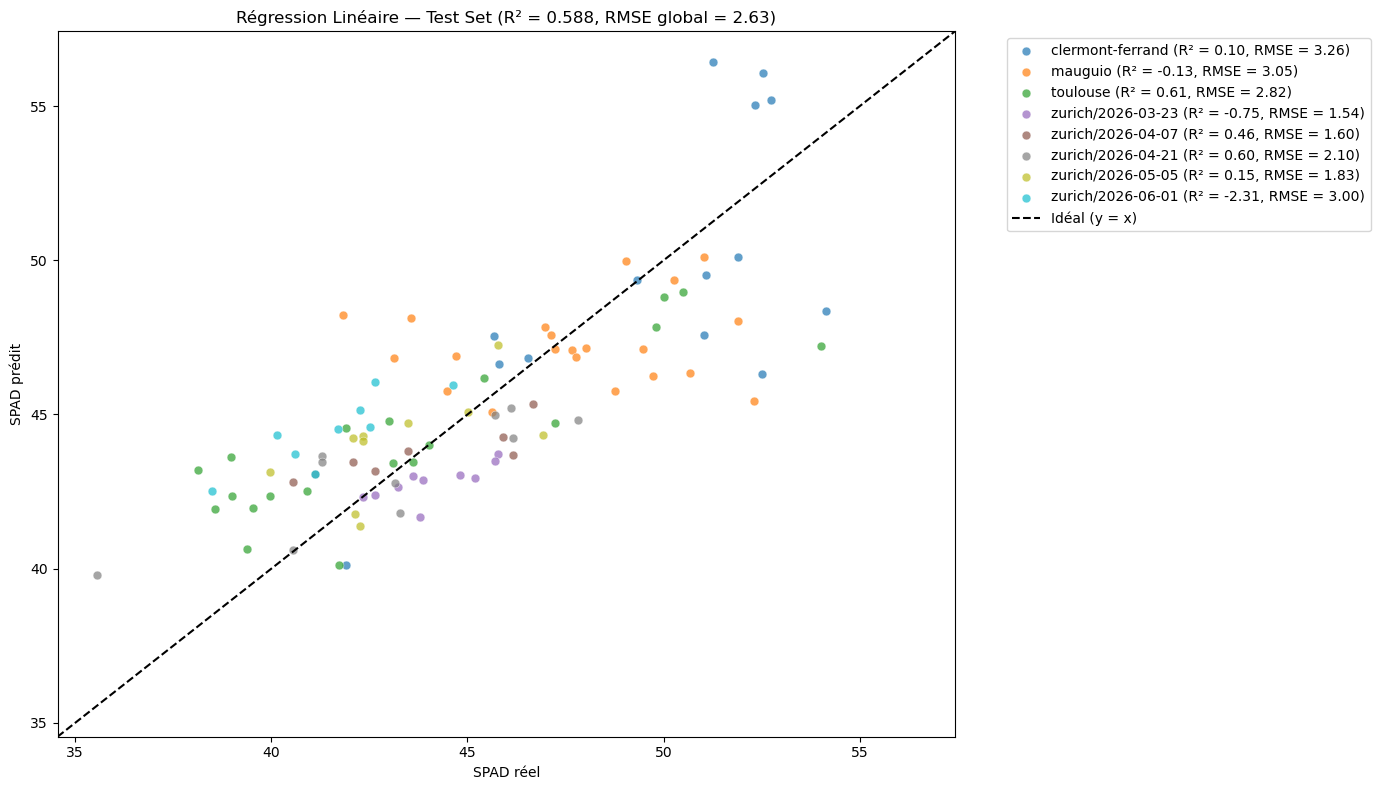

In [102]:
# Calcul de l'RMSE et R² pour chaque site sur le Test Set
test_metrics_per_site = []
sites_test_sorted = sorted(site_test.unique())
for site in sites_test_sorted:
    mask = (site_test == site).values
    rmse_s = np.sqrt(mean_squared_error(y_test.values[mask], y_pred_test[mask]))
    mae_s = mean_absolute_error(y_test.values[mask], y_pred_test[mask])
    r2_s = r2_score(y_test.values[mask], y_pred_test[mask])
    test_metrics_per_site.append({
        "Site": site,
        "N_test": int(mask.sum()),
        "R2": round(r2_s, 3),
        "RMSE": round(rmse_s, 3),
        "MAE": round(mae_s, 3)
    })

test_metrics_df = pd.DataFrame(test_metrics_per_site)
print("=== Métriques par site (Test Set) ===")
print(test_metrics_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(sites_test_sorted)))

for site, color in zip(sites_test_sorted, colors):
    mask = (site_test == site).values
    rmse_s = test_metrics_df.loc[test_metrics_df["Site"] == site, "RMSE"].values[0]
    r2_s = test_metrics_df.loc[test_metrics_df["Site"] == site, "R2"].values[0]
    ax.scatter(
        y_test.values[mask], y_pred_test[mask],
        label=f"{site} (R² = {r2_s:.2f}, RMSE = {rmse_s:.2f})", color=color, alpha=0.7, s=40, edgecolor="white", linewidth=0.4
    )

lims = [
    min(y_test.min(), y_pred_test.min()) - 1,
    max(y_test.max(), y_pred_test.max()) + 1,
]
ax.plot(lims, lims, "k--", label="Idéal (y = x)")

ax.set_xlabel("SPAD réel")
ax.set_ylabel("SPAD prédit")
ax.set_title(f"Régression Linéaire — Test Set (R² = {r2_test:.3f}, RMSE global = {rmse_test:.2f})")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.show()


In [103]:
sites = model_sites.copy()
unique_sites = sorted(sites.unique())
loso_results = []
oof_predictions = pd.Series(index=X.index, dtype=float)

for held_out_site in unique_sites:
    train_mask = sites != held_out_site
    test_mask = sites == held_out_site

    X_tr, y_tr = X[train_mask], y[train_mask]
    X_te, y_te = X[test_mask], y[test_mask]

    # Standardisation : fit uniquement sur le train pour éviter toute fuite
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model = LinearRegression()
    model.fit(X_tr_s, y_tr)
    y_pred = model.predict(X_te_s)

    oof_predictions.loc[X_te.index] = y_pred

    loso_results.append({
        "Site_validation": held_out_site,
        "N_train": len(X_tr),
        "N_val": len(X_te),
        "R2": round(r2_score(y_te, y_pred), 4),
        "MAE": round(mean_absolute_error(y_te, y_pred), 3),
        "RMSE": round(np.sqrt(mean_squared_error(y_te, y_pred)), 3),
    })

loso_results_df = pd.DataFrame(loso_results)
print("=== Résultats — validation par site (Leave-One-Site-Out) ===")
print(loso_results_df.to_string(index=False))
print(f"\nMoyenne R²   : {loso_results_df['R2'].mean():.4f} (± {loso_results_df['R2'].std():.4f})")
print(f"Moyenne MAE  : {loso_results_df['MAE'].mean():.3f}")
print(f"Moyenne RMSE : {loso_results_df['RMSE'].mean():.3f}")

=== Résultats — validation par site (Leave-One-Site-Out) ===
  Site_validation  N_train  N_val      R2   MAE  RMSE
 clermont-ferrand      440     70  0.1163 3.037 3.816
          mauguio      406    104  0.0357 2.725 3.445
         toulouse      411     99  0.4496 2.726 3.229
zurich/2026-03-23      459     51 -2.5421 2.596 2.914
zurich/2026-04-07      474     36 -0.1217 2.025 2.444
zurich/2026-04-21      458     52  0.5851 1.557 1.905
zurich/2026-05-05      458     52  0.3082 1.875 2.415
zurich/2026-06-01      464     46 -1.1621 3.260 3.566

Moyenne R²   : -0.2914 (± 1.0558)
Moyenne MAE  : 2.475
Moyenne RMSE : 2.967


In [104]:
# --- R² et RMSE GLOBAUX de la validation par site (LOSO), calculés sur les prédictions out-of-fold poolées ---
mask_valid = oof_predictions.notna()
r2_global_loso = r2_score(y[mask_valid], oof_predictions[mask_valid])
rmse_global_loso = np.sqrt(mean_squared_error(y[mask_valid], oof_predictions[mask_valid]))
mae_global_loso = mean_absolute_error(y[mask_valid], oof_predictions[mask_valid])
print("=== Métriques GLOBALES — Leave-One-Site-Out (pooled OOF) ===")
print(f"  • R²   global : {r2_global_loso:.4f}")
print(f"  • MAE  global : {mae_global_loso:.3f} unités SPAD")
print(f"  • RMSE global : {rmse_global_loso:.3f} unités SPAD")

=== Métriques GLOBALES — Leave-One-Site-Out (pooled OOF) ===
  • R²   global : 0.4977
  • MAE  global : 2.548 unités SPAD
  • RMSE global : 3.135 unités SPAD


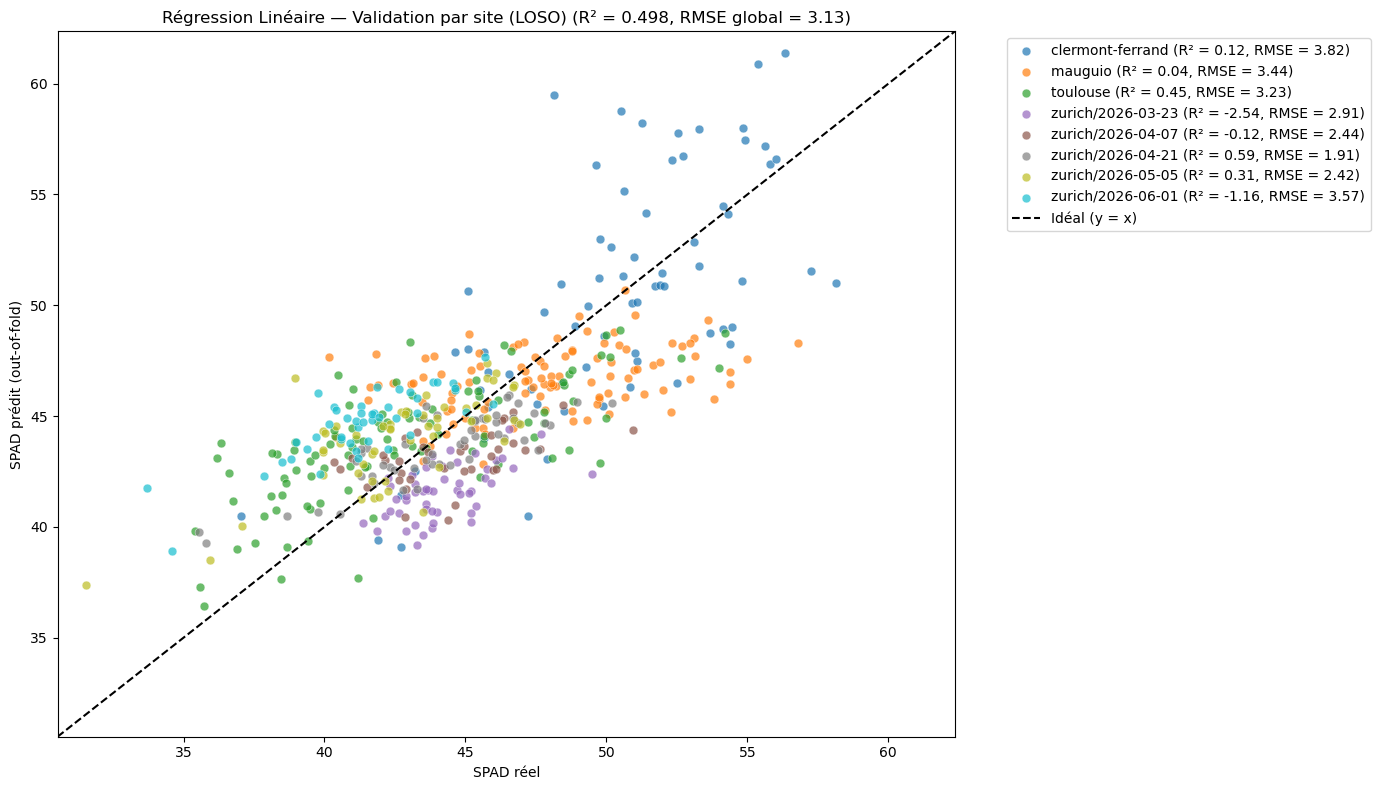

In [105]:
fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_sites)))

for site, color in zip(unique_sites, colors):
    mask = (sites == site).values
    rmse_s = loso_results_df.loc[loso_results_df['Site_validation'] == site, 'RMSE'].values[0]
    r2_s = loso_results_df.loc[loso_results_df['Site_validation'] == site, 'R2'].values[0]
    ax.scatter(
        y.values[mask], oof_predictions.values[mask],
        label=f"{site} (R² = {r2_s:.2f}, RMSE = {rmse_s:.2f})",
        color=color, alpha=0.7, s=40, edgecolor="white", linewidth=0.4
    )

lims = [
    min(y.min(), oof_predictions.min()) - 1,
    max(y.max(), oof_predictions.max()) + 1,
]
ax.plot(lims, lims, "k--", label="Idéal (y = x)")

ax.set_xlabel("SPAD réel")
ax.set_ylabel("SPAD prédit (out-of-fold)")
ax.set_title(f"Régression Linéaire — Validation par site (LOSO) (R² = {r2_global_loso:.3f}, RMSE global = {rmse_global_loso:.2f})")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.show()


## Validation croisée aléatoire (KFold, k=3)

In [106]:
kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
kfold_results = []
oof_predictions_kfold = pd.Series(index=X.index, dtype=float)
for fold_num, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_te, y_te = X.iloc[val_idx], y.iloc[val_idx]
    # Standardisation : fit uniquement sur le train pour éviter toute fuite
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    model = LinearRegression()
    model.fit(X_tr_s, y_tr)
    y_pred = model.predict(X_te_s)
    oof_predictions_kfold.iloc[val_idx] = y_pred
    kfold_results.append({
        "Fold": fold_num,
        "N_train": len(X_tr),
        "N_val": len(X_te),
        "R2": round(r2_score(y_te, y_pred), 4),
        "MAE": round(mean_absolute_error(y_te, y_pred), 3),
        "RMSE": round(np.sqrt(mean_squared_error(y_te, y_pred)), 3),
    })

kfold_results_df = pd.DataFrame(kfold_results)
print("=== Résultats — validation croisée aléatoire (KFold, k=3) ===")
print(kfold_results_df.to_string(index=False))
print(f"\nMoyenne R²   : {kfold_results_df['R2'].mean():.4f} (± {kfold_results_df['R2'].std():.4f})")
print(f"Moyenne RMSE : {kfold_results_df['RMSE'].mean():.3f}")


=== Résultats — validation croisée aléatoire (KFold, k=3) ===
 Fold  N_train  N_val     R2   MAE  RMSE
    1      340    170 0.6099 2.301 2.886
    2      340    170 0.4942 2.314 2.848
    3      340    170 0.5760 2.306 2.996

Moyenne R²   : 0.5600 (± 0.0595)
Moyenne RMSE : 2.910


In [107]:
# --- R² et RMSE GLOBAUX du KFold aléatoire (pooled out-of-fold) ---
r2_global_kfold = r2_score(y, oof_predictions_kfold)
rmse_global_kfold = np.sqrt(mean_squared_error(y, oof_predictions_kfold))
mae_global_kfold = mean_absolute_error(y, oof_predictions_kfold)

print("=== Métriques GLOBALES — KFold aléatoire k=3 (pooled OOF) ===")
print(f"  • R²   global : {r2_global_kfold:.4f}")
print(f"  • MAE  global : {mae_global_kfold:.3f} unités SPAD")
print(f"  • RMSE global : {rmse_global_kfold:.3f} unités SPAD")


=== Métriques GLOBALES — KFold aléatoire k=3 (pooled OOF) ===
  • R²   global : 0.5668
  • MAE  global : 2.307 unités SPAD
  • RMSE global : 2.911 unités SPAD


=== Métriques par site (KFold k=3 OOF) ===
             Site   N     R2  RMSE   MAE
 clermont-ferrand  70  0.259 3.493 2.754
          mauguio 104  0.094 3.339 2.620
         toulouse  99  0.474 3.156 2.626
zurich/2026-03-23  51 -0.469 1.877 1.479
zurich/2026-04-07  36 -0.060 2.377 1.970
zurich/2026-04-21  52  0.590 1.894 1.529
zurich/2026-05-05  52  0.390 2.268 1.738
zurich/2026-06-01  46 -0.792 3.247 2.937


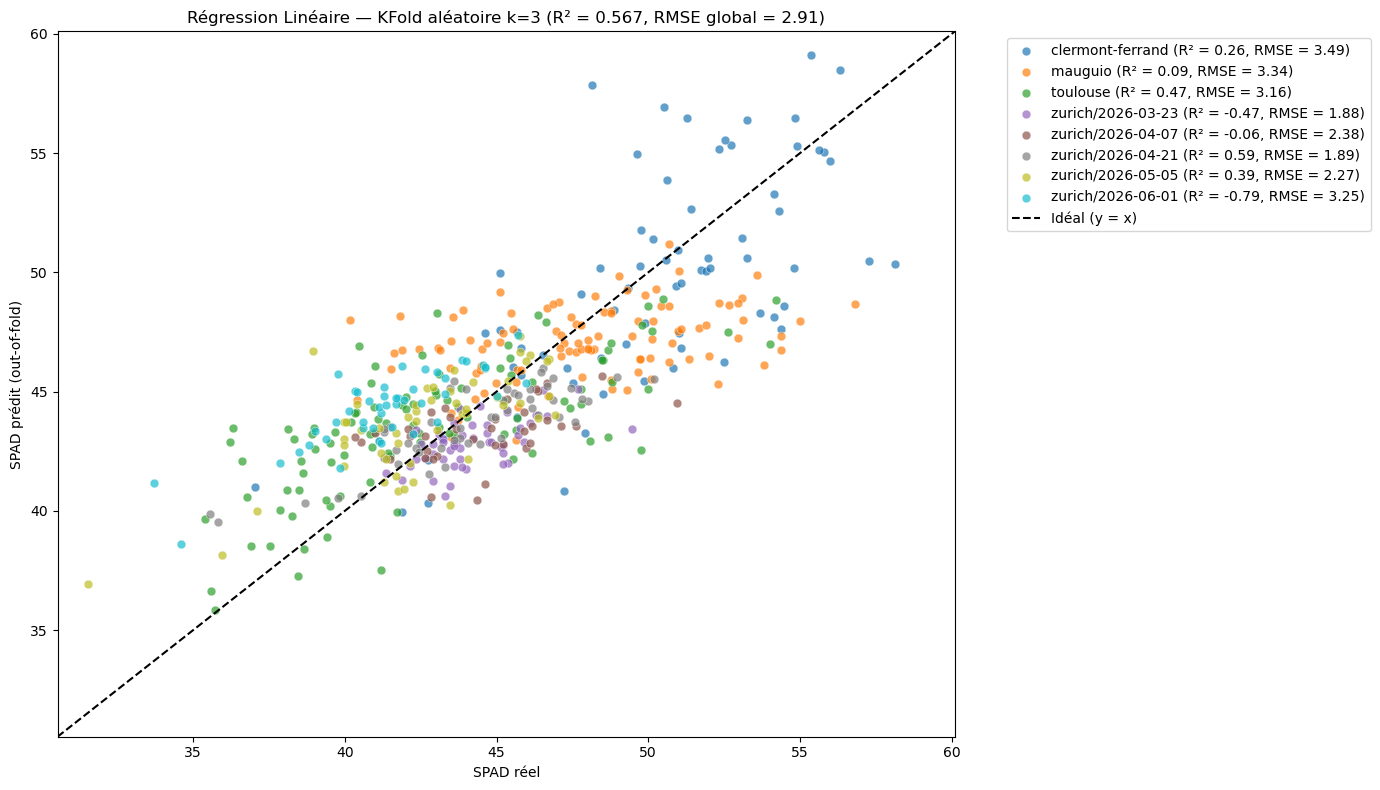

In [108]:
# Calcul de l'RMSE et R² pour chaque site sur les prédictions KFold (OOF)
kfold_metrics_per_site = []
for site in unique_sites:
    mask = (sites == site).values
    rmse_s = np.sqrt(mean_squared_error(y.values[mask], oof_predictions_kfold.values[mask]))
    mae_s = mean_absolute_error(y.values[mask], oof_predictions_kfold.values[mask])
    r2_s = r2_score(y.values[mask], oof_predictions_kfold.values[mask])
    kfold_metrics_per_site.append({
        "Site": site,
        "N": int(mask.sum()),
        "R2": round(r2_s, 3),
        "RMSE": round(rmse_s, 3),
        "MAE": round(mae_s, 3)
    })

kfold_metrics_df = pd.DataFrame(kfold_metrics_per_site)
print("=== Métriques par site (KFold k=3 OOF) ===")
print(kfold_metrics_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 8))
colors_kf = plt.cm.tab10(np.linspace(0, 1, len(unique_sites)))

for site, color in zip(unique_sites, colors_kf):
    mask = (sites == site).values
    rmse_s = kfold_metrics_df.loc[kfold_metrics_df["Site"] == site, "RMSE"].values[0]
    r2_s = kfold_metrics_df.loc[kfold_metrics_df["Site"] == site, "R2"].values[0]
    ax.scatter(
        y.values[mask], oof_predictions_kfold.values[mask],
        label=f"{site} (R² = {r2_s:.2f}, RMSE = {rmse_s:.2f})", color=color, alpha=0.7, s=40, edgecolor="white", linewidth=0.4
    )

lims = [
    min(y.min(), oof_predictions_kfold.min()) - 1,
    max(y.max(), oof_predictions_kfold.max()) + 1,
]
ax.plot(lims, lims, "k--", label="Idéal (y = x)")

ax.set_xlabel("SPAD réel")
ax.set_ylabel("SPAD prédit (out-of-fold)")
ax.set_title(f"Régression Linéaire — KFold aléatoire k=3 (R² = {r2_global_kfold:.3f}, RMSE global = {rmse_global_kfold:.2f})")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.show()


## Analyse de corrélation : SPAD (`spad_mean`) vs `Mean_rb_index`


=== Correlation globale SPAD vs Mean_rb_index ===
  Pearson r   : -0.7526 (p-value = 3.01e-94)
  Spearman rho: -0.7330 (p-value = 4.68e-87)
  Observations: 510

=== Correlation par site ===
             Site   N  Pearson_r  p-value
 clermont-ferrand  70    -0.6940 2.72e-11
          mauguio 104    -0.3778 7.69e-05
         toulouse  99    -0.6917 2.26e-15
zurich/2026-03-23  51    -0.5849 6.55e-06
zurich/2026-04-07  36    -0.4771 3.26e-03
zurich/2026-04-21  52    -0.8410 6.11e-15
zurich/2026-05-05  52    -0.7031 6.16e-09
zurich/2026-06-01  46    -0.8113 8.07e-12


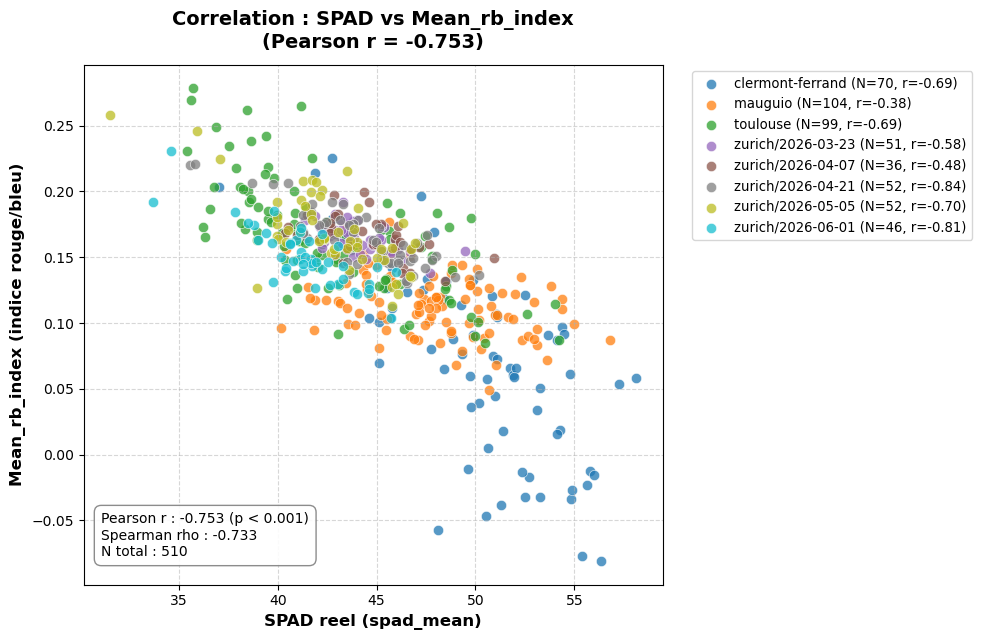

In [109]:
from scipy import stats

corr_x = df["Mean_rb_index"]
corr_y = df["spad_mean"]

r_val, p_val = stats.pearsonr(corr_x, corr_y)
r_spearman, p_spearman = stats.spearmanr(corr_x, corr_y)

print("=== Correlation globale SPAD vs Mean_rb_index ===")
print(f"  Pearson r   : {r_val:.4f} (p-value = {p_val:.2e})")
print(f"  Spearman rho: {r_spearman:.4f} (p-value = {p_spearman:.2e})")
print(f"  Observations: {len(df)}")

print("\n=== Correlation par site ===")
correlation_sites = sorted(df["Site"].unique())
site_corrs = []
for site in correlation_sites:
    mask = df["Site"] == site
    site_spad = df.loc[mask, "spad_mean"]
    site_index = df.loc[mask, "Mean_rb_index"]
    if len(site_spad) > 2:
        r_site, p_site = stats.pearsonr(site_spad, site_index)
        site_corrs.append({
            "Site": site, "N": len(site_spad),
            "Pearson_r": round(r_site, 4), "p-value": f"{p_site:.2e}",
        })
    else:
        site_corrs.append({
            "Site": site, "N": len(site_spad),
            "Pearson_r": np.nan, "p-value": "N/A",
        })
print(pd.DataFrame(site_corrs).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=100)
colors = plt.cm.tab10(np.linspace(0, 1, len(correlation_sites)))

for site, color in zip(correlation_sites, colors):
    mask = df["Site"] == site
    site_spad = df.loc[mask, "spad_mean"]
    site_index = df.loc[mask, "Mean_rb_index"]
    r_site = stats.pearsonr(site_spad, site_index)[0] if len(site_spad) > 2 else np.nan
    ax.scatter(
        site_spad, site_index,
        label=f"{site} (N={len(site_spad)}, r={r_site:.2f})",
        color=color, alpha=0.75, s=55, edgecolor="white", linewidth=0.5,
    )

ax.set_xlabel("SPAD reel (spad_mean)", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean_rb_index (indice rouge/bleu)", fontsize=12, fontweight="bold")
ax.set_title(
    f"Correlation : SPAD vs Mean_rb_index\n(Pearson r = {r_val:.3f})",
    fontsize=14, fontweight="bold", pad=12,
)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True, fontsize=9.5)

stats_box = (
    f"Pearson r : {r_val:.3f} (p < 0.001)\n"
    f"Spearman rho : {r_spearman:.3f}\n"
    f"N total : {len(df)}"
)
ax.text(
    0.03, 0.05, stats_box, transform=ax.transAxes, fontsize=10,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
)

plt.tight_layout()
plt.show()
